# 02 - Preprocessing

This notebook builds the cleaned, encoded, and scaled dataset. It samples 10,000 rows first, then handles missing values, duplicates, outliers, encoding, scaling, and train/test splitting before saving reusable artifacts for clustering and classification.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

BASE_DIR = Path('..').resolve()
DATA_PATH = BASE_DIR / 'data' / 'raw' / 'raw_data.csv'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PLOTS_DIR = BASE_DIR / 'plots' / 'preprocessing'
MODELS_DIR = BASE_DIR / 'models'
for folder in [PROCESSED_DIR, PLOTS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'LoanApproved'
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
print('Original shape:', df.shape)
df = df.sample(10000, random_state=RANDOM_STATE).reset_index(drop=True)
print('After sampling 10,000 rows:', df.shape)
df.head()

Original shape: (20000, 36)
After sampling 10,000 rows: (10000, 36)


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2047-02-28,37,100761,604,Employed,High School,16,28479,84,Single,0,Mortgage,88,0.280949,3,1,0.430751,0,Debt Consolidation,0,23,19,2254,1421,10213,2909,8396.750000,0.809983,7,7304,0.251479,0.222397,671.369324,0.090436,1,41.6
1,2023-08-04,35,189154,509,Employed,High School,11,11222,60,Married,2,Mortgage,411,0.289522,2,4,0.148908,0,Debt Consolidation,0,30,12,4456,3706,42599,20156,15762.833333,0.831507,7,22443,0.261722,0.270451,342.970300,0.047832,1,38.4
2,2041-09-25,44,73272,483,Employed,High School,20,31573,48,Widowed,0,Own,442,0.513947,4,1,0.206626,0,Home,0,21,25,5212,1619,75175,55131,6106.000000,0.800830,1,20044,0.285073,0.342088,1215.387601,0.271436,0,53.0
3,2021-01-19,41,57115,412,Employed,Master,20,21937,12,Married,3,Rent,409,0.256789,1,1,0.184681,0,Debt Consolidation,0,23,14,5046,1389,6435,40497,4759.583333,0.954407,5,1714,0.280937,0.280613,2117.710361,0.530868,0,50.0
4,2056-01-24,39,61155,551,Employed,Master,19,31510,48,Divorced,0,Rent,533,0.216696,6,1,0.184185,0,Debt Consolidation,0,19,3,9010,2117,72697,16756,5096.250000,0.840267,3,55941,0.251010,0.250815,1046.213156,0.309877,0,51.0


## Missing values and duplicates
Numeric columns are filled with the median and categorical columns with the mode, then duplicate rows are removed.

Missing values before imputation:
ApplicationDate     0
Age                 0
AnnualIncome        0
CreditScore         0
EmploymentStatus    0
EducationLevel      0
Experience          0
LoanAmount          0
LoanDuration        0
MaritalStatus       0
dtype: int64
Duplicates removed: 0
Shape after duplicate removal: (10000, 36)


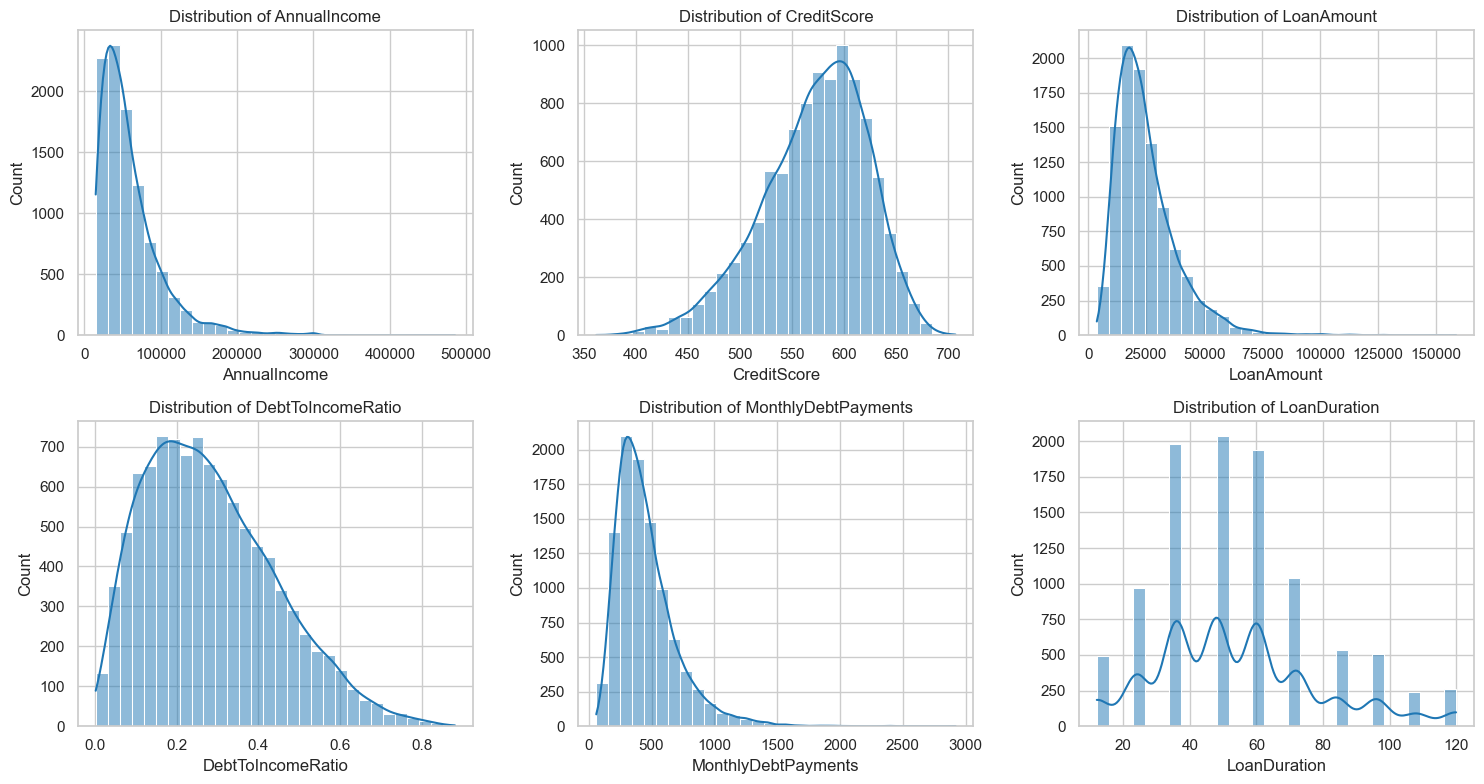

In [2]:
print('Missing values before imputation:')
print(df.isna().sum().sort_values(ascending=False).head(10))

numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()

for column in numeric_cols:
    df[column] = df[column].fillna(df[column].median())
for column in categorical_cols:
    df[column] = df[column].fillna(df[column].mode(dropna=True)[0])

before_duplicates = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicates removed: {before_duplicates - df.shape[0]}')
print('Shape after duplicate removal:', df.shape)

main_features = [
    'AnnualIncome',
    'CreditScore',
    'LoanAmount',
    'DebtToIncomeRatio',
    'MonthlyDebtPayments',
    'LoanDuration',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, column in enumerate(main_features):
    sns.histplot(df[column], kde=True, bins=30, ax=axes[idx], color='#1f77b4')
    axes[idx].set_title(f'Distribution of {column}')
    axes[idx].set_xlabel(column)
    axes[idx].set_ylabel('Count')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

## Outlier handling
The IQR method caps outliers in numeric features to reduce the influence of extreme values without discarding too many rows.

Outliers capped using IQR on 24 columns.
Shape after outlier handling: (10000, 36)
Target distribution after outlier handling:
LoanApproved
0    7555
1    2445
Name: count, dtype: int64


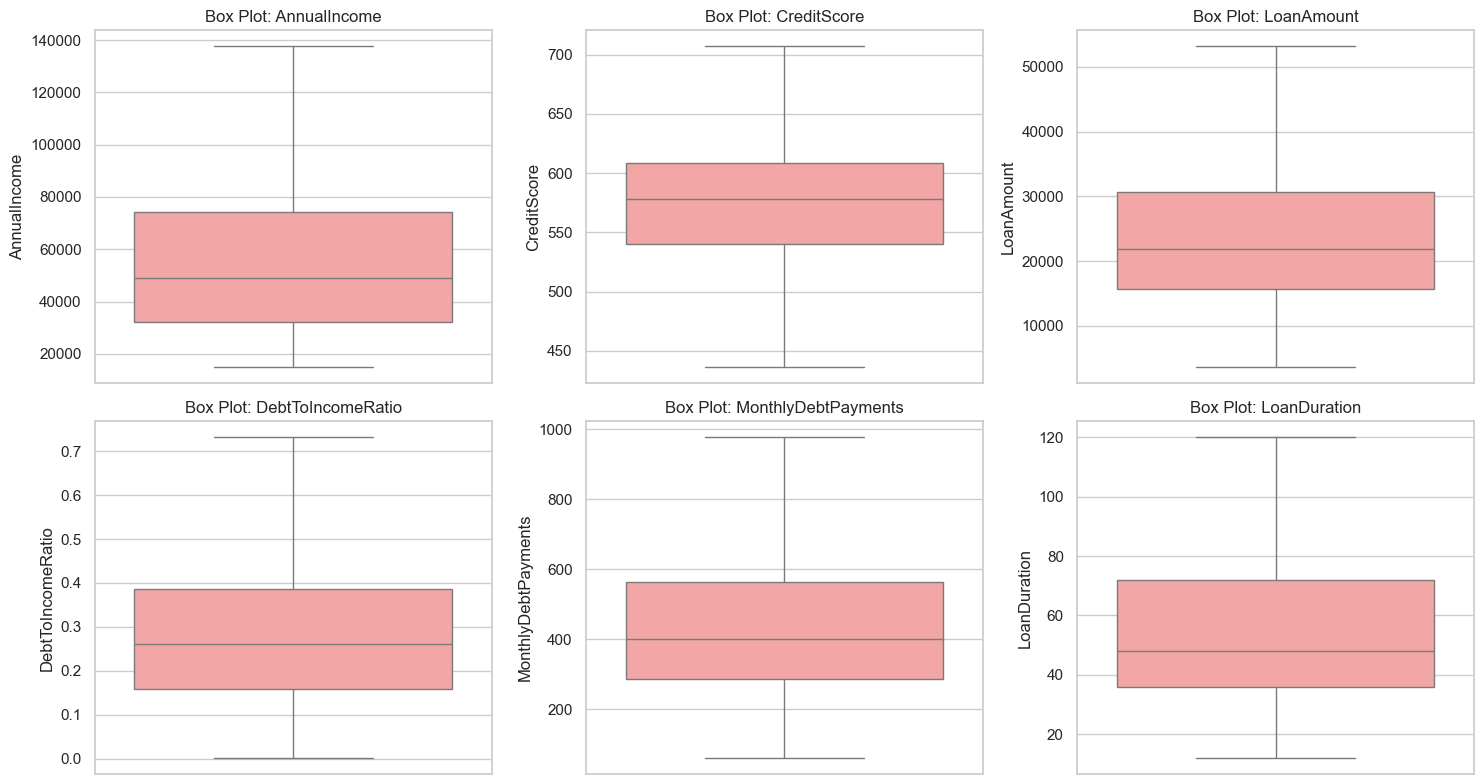

In [3]:
def cap_outliers_iqr(frame, columns):
    capped = frame.copy()
    for column in columns:
        q1 = capped[column].quantile(0.25)
        q3 = capped[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        capped[column] = capped[column].clip(lower_bound, upper_bound)
    return capped

# Exclude target and low-cardinality numeric columns (e.g., binary flags) from IQR capping.
outlier_cols = [
    column for column in numeric_cols
    if column != TARGET_COL and df[column].nunique(dropna=False) > 10
]

df = cap_outliers_iqr(df, outlier_cols)
print(f'Outliers capped using IQR on {len(outlier_cols)} columns.')
print('Shape after outlier handling:', df.shape)
print('Target distribution after outlier handling:')
print(df[TARGET_COL].value_counts())

main_features = [
    'AnnualIncome',
    'CreditScore',
    'LoanAmount',
    'DebtToIncomeRatio',
    'MonthlyDebtPayments',
    'LoanDuration',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, column in enumerate(main_features):
    sns.boxplot(y=df[column], ax=axes[idx], color='#ff9999')
    axes[idx].set_title(f'Box Plot: {column}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(column)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'boxplots_outlier_handling.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

## Encoding and split
Categorical columns are label-encoded, the target is separated, scaling is applied, and the dataset is split into train and test sets.

In [4]:
encoders = {}
for column in categorical_cols:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column].astype(str))
    encoders[column] = encoder

# Drop target column and RiskScore (data leakage - directly encodes the target)
columns_to_drop = [TARGET_COL, 'RiskScore']
X = df.drop(columns=columns_to_drop)
y = df[TARGET_COL].astype(int)
print('Features shape:', X.shape)
print('Target shape:', y.shape)

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print('Scaler saved to', MODELS_DIR / 'scaler.pkl')

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Features shape: (10000, 34)
Target shape: (10000,)
Scaler saved to D:\Financial-Risk-Classification-and-Behavioral-Pattern-Clustering\models\scaler.pkl
Train shape: (8000, 34) (8000,)
Test shape: (2000, 34) (2000,)


## Class distribution and saved artifacts
The class distribution is shown once before model training, and all reusable preprocessing outputs are saved to disk.

Current target counts from dataframe:
LoanApproved
0    7555
1    2445
Name: count, dtype: int64
y_train class counts:
LoanApproved
0    6044
1    1956
Name: count, dtype: int64


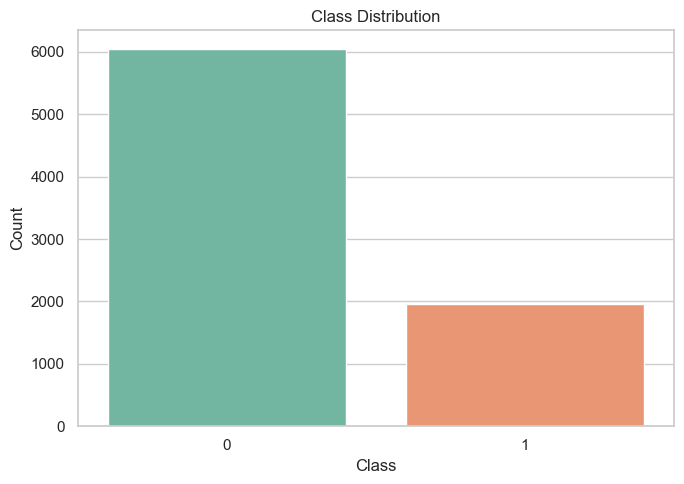

Saved processed datasets, encoders, and scaler.
Preprocessing complete. Final processed sample shape: (10000, 36)


In [5]:
def plot_class_distribution(values, title, file_name):
    plt.figure(figsize=(7, 5))
    sns.countplot(x=values, hue=values, palette='Set2', legend=False)
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / file_name, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

X_current = df.drop(columns=[TARGET_COL, 'RiskScore'])
y_current = df[TARGET_COL].astype(int)

print('Current target counts from dataframe:')
print(y_current.value_counts())

if y_current.nunique() < 2:
    raise ValueError('Target column has only one class in the current dataframe. Check preprocessing steps before train/test split.')

X_scaled_current = pd.DataFrame(scaler.fit_transform(X_current), columns=X_current.columns)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_current, y_current, test_size=0.2, random_state=RANDOM_STATE, stratify=y_current
)

print('y_train class counts:')
print(y_train.value_counts())
plot_class_distribution(y_train, 'Class Distribution', 'class_distribution.png')

X_train.to_csv(PROCESSED_DIR / 'X_train.csv', index=False)
X_test.to_csv(PROCESSED_DIR / 'X_test.csv', index=False)
y_train.to_csv(PROCESSED_DIR / 'y_train.csv', index=False)
y_test.to_csv(PROCESSED_DIR / 'y_test.csv', index=False)
X_scaled_current.to_csv(PROCESSED_DIR / 'X_scaled.csv', index=False)
df.to_csv(PROCESSED_DIR / 'preprocessed_sample.csv', index=False)

joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
joblib.dump(encoders, MODELS_DIR / 'label_encoders.pkl')
print('Saved processed datasets, encoders, and scaler.')
print('Preprocessing complete. Final processed sample shape:', df.shape)